# Neural Network using TensorFlow (Low-Level API)
Build a feedforward neural network using TensorFlow 1.x style (placeholders, sessions).

In [1]:
!pip install tensorflow==2.12.0 numpy scikit-learn

Defaulting to user installation because normal site-packages is not writeable

ERROR: Could not find a version that satisfies the requirement tensorflow==2.12.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)

[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tensorflow==2.12.0


In [2]:
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Generate dummy dataset
X, y = make_classification(n_samples=1000, n_features=10, random_state=42)
y = y.reshape(-1, 1).astype(np.float32)
X = X.astype(np.float32)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('Data ready. X_train shape:', X_train.shape)


Instructions for updating:
non-resource variables are not supported in the long term
Data ready. X_train shape: (800, 10)


In [3]:
# Hyperparameters
n_input = 10
n_hidden1 = 64
n_hidden2 = 32
n_output = 1
learning_rate = 0.01
epochs = 100
batch_size = 32

# Placeholders (TF1 style)
X_ph = tf.placeholder(tf.float32, shape=[None, n_input], name='X')
y_ph = tf.placeholder(tf.float32, shape=[None, 1], name='y')

# Manual weight initialization
def init_weights(shape, name):
    return tf.Variable(tf.random_normal(shape, stddev=0.1), name=name)

W1 = init_weights([n_input, n_hidden1], 'W1')
b1 = tf.Variable(tf.zeros([n_hidden1]), name='b1')
W2 = init_weights([n_hidden1, n_hidden2], 'W2')
b2 = tf.Variable(tf.zeros([n_hidden2]), name='b2')
W3 = init_weights([n_hidden2, n_output], 'W3')
b3 = tf.Variable(tf.zeros([n_output]), name='b3')

print('Weights initialized.')

Weights initialized.


In [4]:
# Build computation graph
h1 = tf.nn.relu(tf.matmul(X_ph, W1) + b1)
h2 = tf.nn.relu(tf.matmul(h1, W2) + b2)
logits = tf.matmul(h2, W3) + b3
output = tf.sigmoid(logits)

loss = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(labels=y_ph, logits=logits))
optimizer = tf.train.AdamOptimizer(learning_rate).minimize(loss)

correct = tf.equal(tf.round(output), y_ph)
accuracy = tf.reduce_mean(tf.cast(correct, tf.float32))

print('Computation graph built.')


Computation graph built.


In [5]:
# Training using sessions
init = tf.global_variables_initializer()
loss_history = []

with tf.Session() as sess:
    sess.run(init)
    for epoch in range(epochs):
        indices = np.random.permutation(len(X_train))
        epoch_loss = 0
        for i in range(0, len(X_train), batch_size):
            batch_idx = indices[i:i+batch_size]
            Xb = X_train[batch_idx]
            yb = y_train[batch_idx]
            _, l = sess.run([optimizer, loss], feed_dict={X_ph: Xb, y_ph: yb})
            epoch_loss += l
        loss_history.append(epoch_loss)
        if (epoch+1) % 10 == 0:
            acc = sess.run(accuracy, feed_dict={X_ph: X_test, y_ph: y_test})
            print(f'Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Test Acc: {acc:.4f}')
    final_acc = sess.run(accuracy, feed_dict={X_ph: X_test, y_ph: y_test})
    print(f'\nFinal Test Accuracy: {final_acc:.4f}')

Epoch 10/100 | Loss: 5.5686 | Test Acc: 0.8650
Epoch 20/100 | Loss: 3.6544 | Test Acc: 0.8700
Epoch 30/100 | Loss: 1.4636 | Test Acc: 0.8550
Epoch 40/100 | Loss: 0.4174 | Test Acc: 0.8650
Epoch 50/100 | Loss: 1.8001 | Test Acc: 0.8500
Epoch 60/100 | Loss: 0.2855 | Test Acc: 0.8600
Epoch 70/100 | Loss: 0.0849 | Test Acc: 0.8550
Epoch 80/100 | Loss: 0.0588 | Test Acc: 0.8550
Epoch 90/100 | Loss: 0.0458 | Test Acc: 0.8550
Epoch 100/100 | Loss: 0.0416 | Test Acc: 0.8600

Final Test Accuracy: 0.8600


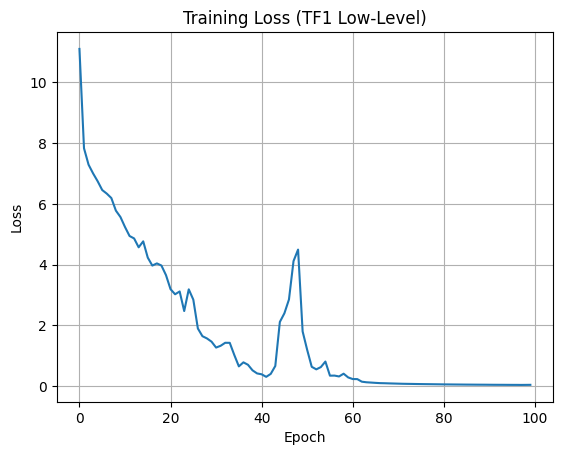

In [6]:
import matplotlib.pyplot as plt
plt.plot(loss_history)
plt.title('Training Loss (TF1 Low-Level)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [7]:
plt.savefig("plot.png")

<Figure size 640x480 with 0 Axes>